# Práctica Final - Machine Learning / IA

## Objetivo
Resolver un problema de clasificación sobre el dataset `cybersecurity_attacks.csv`.

Targets disponibles:
- `Action Taken` (obligatorio)
- `Severity Level` (opcional)
- `Attack Type` (opcional)

En esta primera fase se realizará:
1. Carga de datos
2. Inspección inicial de la data facilitada
3. Análisis exploratorio básico inicial de la data facilitada
4. Detección de problemas de calidad de datos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/cybersecurity_attacks.csv")

In [3]:
import sklearn
sklearn.__version__

'1.6.1'

In [4]:
df.shape

(40000, 25)

In [5]:
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [7]:
df.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


In [8]:
df.describe(include="object").T

,count,unique,top,freq
Timestamp,40000,39997,2022-06-11 14:28:15,2
Source IP Address,40000,40000,103.216.15.12,1
Destination IP Address,40000,40000,84.9.164.252,1
Protocol,40000,3,ICMP,13429
Packet Type,40000,2,Control,20237
Traffic Type,40000,3,DNS,13376
Payload Data,40000,40000,Qui natus odio asperiores nam. Optio nobis ius...,1
Malware Indicators,20000,1,IoC Detected,20000
Alerts/Warnings,19933,1,Alert Triggered,19933
Attack Type,40000,3,DDoS,13428


In [9]:
for col in ["Action Taken", "Severity Level", "Attack Type"]:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False))


===== Action Taken =====
Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

===== Severity Level =====
Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64

===== Attack Type =====
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


## Calidad de datos

En este bloque revisamos:
- valores nulos
- filas duplicadas
- distribución de las variables objetivo

Este análisis es importante porque el dataset contiene datos reales y, como indica el enunciado,
puede requerir más limpieza que los conjuntos de datos vistos durante las clases.

In [10]:
null_counts = df.isna().sum().sort_values(ascending=False)
null_pct = (df.isna().mean() * 100).sort_values(ascending=False)

nulls_summary = pd.DataFrame({
    "nulos": null_counts,
    "porcentaje": null_pct
})

nulls_summary

,nulos,porcentaje
Alerts/Warnings,20067,50.1675
IDS/IPS Alerts,20050,50.1250
Malware Indicators,20000,50.0000
Firewall Logs,19961,49.9025
Proxy Information,19851,49.6275
Attack Type,0,0.0000
Geo-location Data,0,0.0000
Network Segment,0,0.0000
Device Information,0,0.0000
User Information,0,0.0000


In [11]:
# Filas duplicadas
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [12]:
# Distribución de targets
targets = ["Action Taken", "Severity Level", "Attack Type"]

for col in targets:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts(dropna=False))
    print("\nPorcentajes:")
    print(df[col].value_counts(normalize=True, dropna=False).mul(100).round(2))


Distribución de Action Taken:
Action Taken
Blocked    13529
Ignored    13276
Logged     13195
Name: count, dtype: int64

Porcentajes:
Action Taken
Blocked    33.82
Ignored    33.19
Logged     32.99
Name: proportion, dtype: float64

Distribución de Severity Level:
Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64

Porcentajes:
Severity Level
Medium    33.59
High      33.46
Low       32.96
Name: proportion, dtype: float64

Distribución de Attack Type:
Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64

Porcentajes:
Attack Type
DDoS         33.57
Malware      33.27
Intrusion    33.16
Name: proportion, dtype: float64


In [13]:
df.nunique().sort_values(ascending=False)

Payload Data              40000
Source IP Address         40000
Destination IP Address    40000
Timestamp                 39997
User Information          32389
Device Information        32104
Destination Port          29895
Source Port               29761
Proxy Information         20148
Anomaly Scores             9826
Geo-location Data          8723
Packet Length              1437
Protocol                      3
Traffic Type                  3
Attack Type                   3
Network Segment               3
Action Taken                  3
Severity Level                3
Log Source                    2
Attack Signature              2
Packet Type                   2
Malware Indicators            1
Firewall Logs                 1
IDS/IPS Alerts                1
Alerts/Warnings               1
dtype: int64

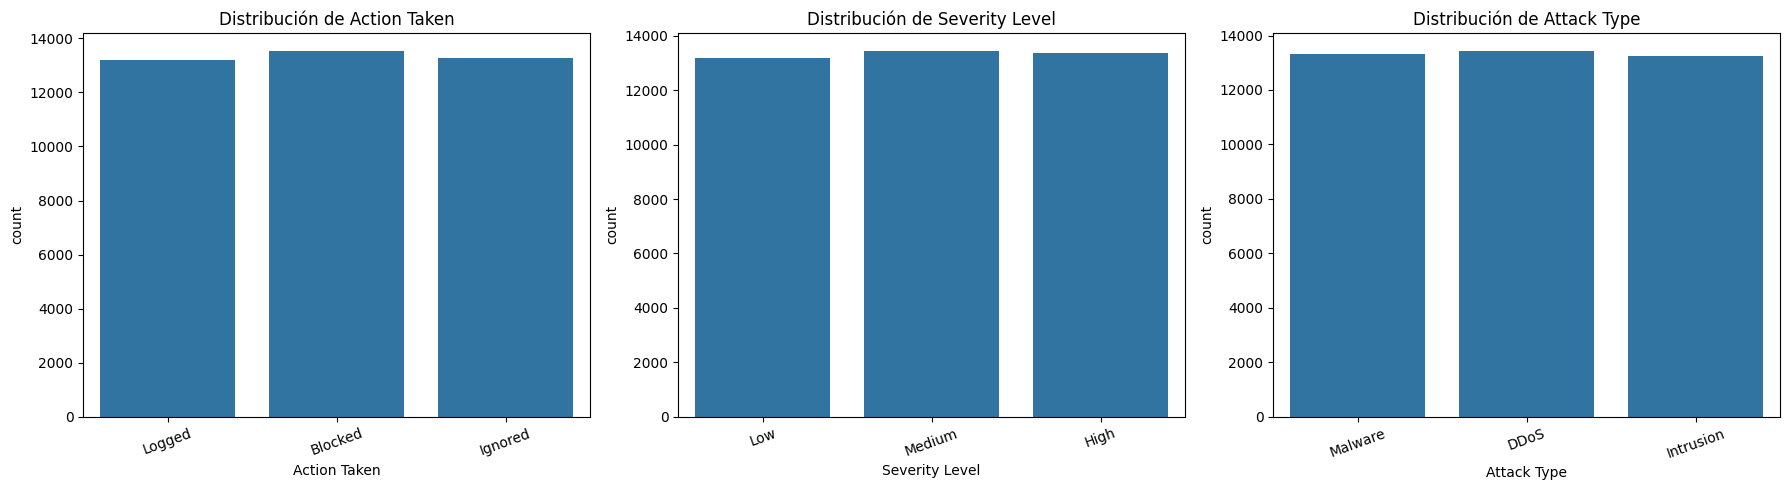

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, targets):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribución de {col}")
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Análisis exploratorio de variables

Una vez revisada la calidad general del dataset, analizamos ahora la naturaleza de las variables:
- separación entre variables numéricas y categóricas
- correlación entre variables numéricas
- presencia de posibles valores atípicos
- cardinalidad de variables categóricas

Este paso permite entender mejor la estructura del problema antes de decidir qué transformaciones aplicar en la fase de preprocesado.

In [15]:
# Separación de variables numéricas y categóricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Columnas numéricas:")
print(num_cols)
print("\nNúmero de columnas numéricas:", len(num_cols))

print("\nColumnas categóricas:")
print(cat_cols)
print("\nNúmero de columnas categóricas:", len(cat_cols))

Columnas numéricas:
['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']

Número de columnas numéricas: 4

Columnas categóricas:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Protocol', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']

Número de columnas categóricas: 21


## Variables numéricas y categóricas

En este bloque se revisan las variables numéricas y categóricas del dataset para entender mejor su naturaleza.
Además, se analiza la correlación entre variables numéricas y la presencia de posibles valores atípicos.


In [16]:
# Resumen estadístico de variables numéricas
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Source Port,40000.0,32970.356450,18560.425604,1027.0,16850.75,32856.000,48928.25,65530.0
Destination Port,40000.0,33150.868650,18574.668842,1024.0,17094.75,33004.500,49287.00,65535.0
Packet Length,40000.0,781.452725,416.044192,64.0,420.00,782.000,1143.00,1500.0
Anomaly Scores,40000.0,50.113473,28.853598,0.0,25.15,50.345,75.03,100.0


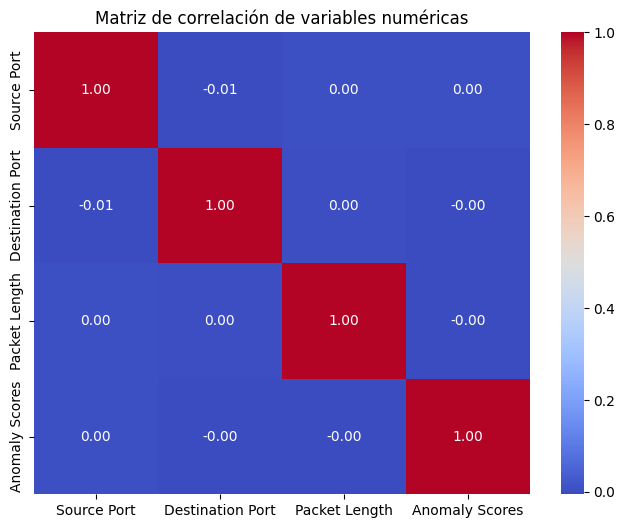

In [17]:
# Matriz de correlación de variables numéricas
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

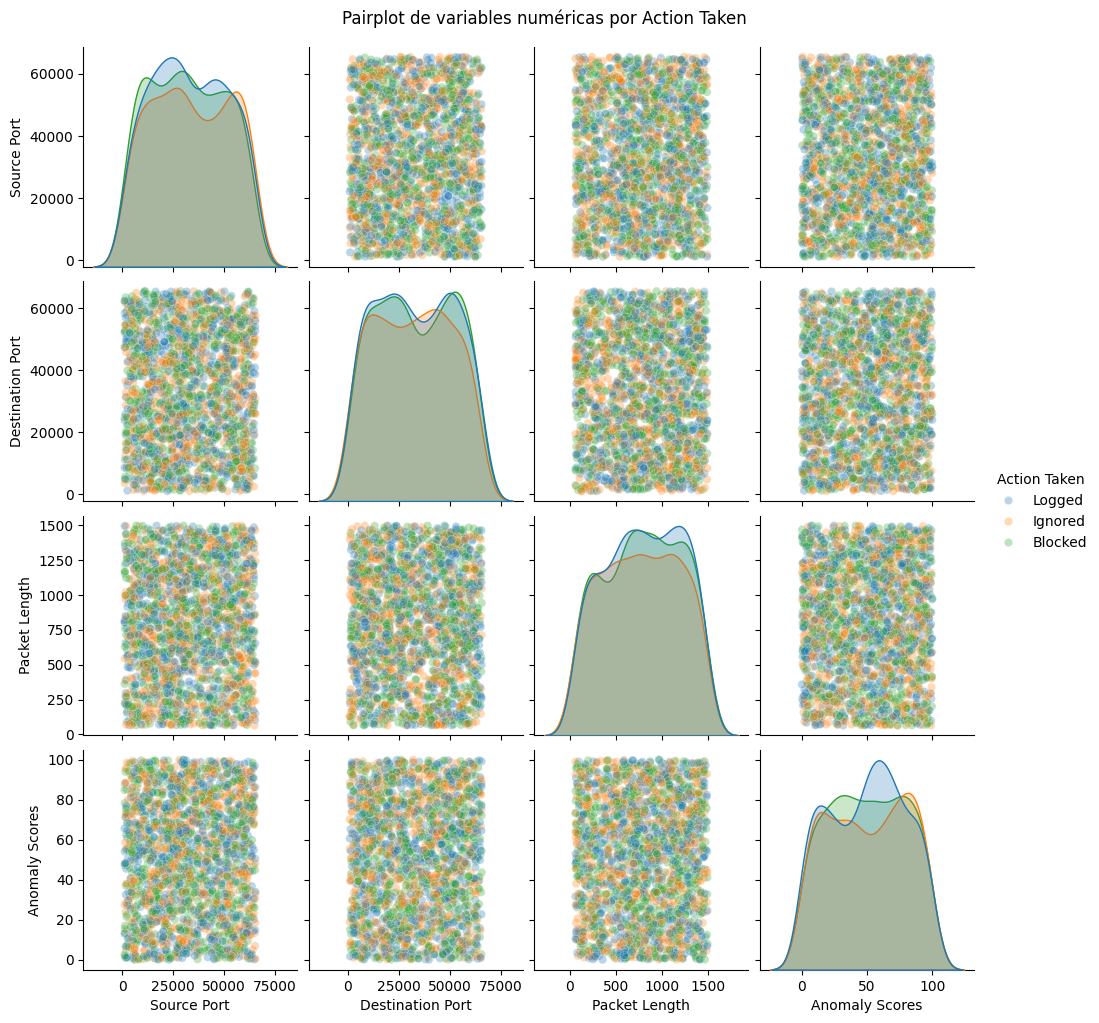

In [18]:
# Pairplot de numéricas coloreado por Action Taken
# (muestra distribución y relación entre variables simultáneamente)
import seaborn as sns

sample = df[num_cols + ["Action Taken"]].sample(2000, random_state=42)
sns.pairplot(sample, hue="Action Taken", plot_kws={"alpha": 0.3}, height=2.5)
plt.suptitle("Pairplot de variables numéricas por Action Taken", y=1.02)
plt.show()

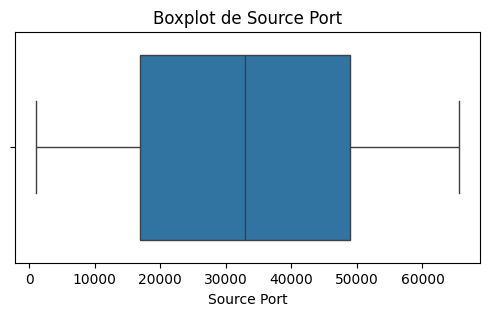

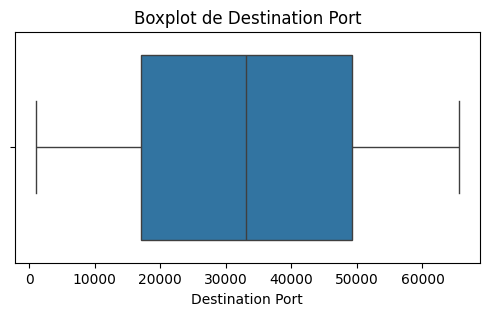

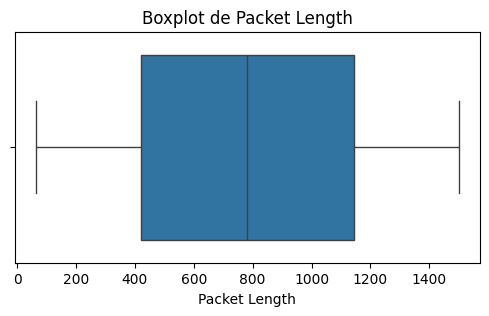

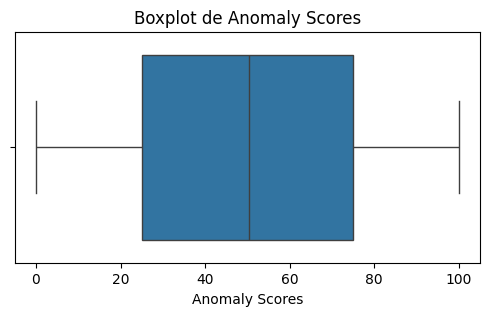

In [19]:
# Boxplots de variables numéricas
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [20]:
# Cardinalidad de variables categóricas
df[cat_cols].nunique().sort_values(ascending=False)

Destination IP Address    40000
Payload Data              40000
Source IP Address         40000
Timestamp                 39997
User Information          32389
Device Information        32104
Proxy Information         20148
Geo-location Data          8723
Protocol                      3
Traffic Type                  3
Network Segment               3
Attack Type                   3
Action Taken                  3
Severity Level                3
Attack Signature              2
Packet Type                   2
Log Source                    2
Alerts/Warnings               1
Malware Indicators            1
Firewall Logs                 1
IDS/IPS Alerts                1
dtype: int64

## Interpretación inicial del análisis exploratorio

A partir del análisis exploratorio realizado, se observan varios puntos relevantes:

- El problema es de **clasificación multiclase**.
- El dataset contiene una mezcla de variables numéricas y categóricas.
- Existen columnas con alta cardinalidad, como identificadores, IPs, timestamps o nombres de usuario, que requieren tratamiento específico.
- También hay columnas con valores nulos relevantes, especialmente en campos relacionados con logs, alertas e indicadores.
- La correlación lineal entre variables numéricas sirve como referencia inicial, pero no será suficiente por sí sola para seleccionar variables, ya que gran parte de la información del problema está en variables categóricas.
- Antes de entrenar modelos, es necesario definir una estrategia de preprocesado coherente y evitar posibles problemas de data leakage.

## Decisiones de preprocesado para el target `Action Taken`

En esta práctica se comenzará modelando la variable objetivo **Action Taken**, ya que es la exigida como mínimo en el enunciado.

Antes de entrenar modelos, definimos cómo tratar cada grupo de variables:

- **Variables objetivo secundarias** (`Severity Level`, `Attack Type`): se excluirán del modelo principal para evitar leakage, ya que también son targets del mismo dataset.
- **Timestamp**: se transformará en variables temporales útiles (año, mes, día, hora, día de la semana) y posteriormente se eliminará la columna original.
- **IPs, username, device information y similares**: se revisarán por su alta cardinalidad y por su posible escasa capacidad de generalización.
- **Columnas con muchos nulos**: se evaluará si conviene imputarlas, transformarlas a variables binarias de presencia/ausencia, o eliminarlas.
- **Variables categóricas**: se codificarán posteriormente para permitir el entrenamiento de modelos de clasificación.

In [21]:
target_main = "Action Taken"
other_targets = ["Severity Level", "Attack Type"]

print("Target principal:", target_main)
print("Targets a excluir del modelo principal:", other_targets)
print("\nColumnas del dataset:")
print(df.columns.tolist())

Target principal: Action Taken
Targets a excluir del modelo principal: ['Severity Level', 'Attack Type']

Columnas del dataset:
['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


In [22]:
# Información mutua: variables numéricas vs Action Taken
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df["Action Taken"])

mi_scores = mutual_info_classif(df[num_cols], y_encoded, random_state=42)
mi_df = (pd.DataFrame({"feature": num_cols, "mutual_info": mi_scores})
           .sort_values("mutual_info", ascending=False))
print("Información mutua — numéricas vs Action Taken:")
print(mi_df.to_string(index=False))

Información mutua — numéricas vs Action Taken:
         feature  mutual_info
     Source Port     0.005209
  Anomaly Scores     0.000892
Destination Port     0.000000
   Packet Length     0.000000


In [23]:
# Relación entre categóricas de baja cardinalidad y Action Taken
cat_low = ["Protocol", "Packet Type", "Traffic Type", 
           "Network Segment", "Log Source", "Attack Signature"]

for col in cat_low:
    print(f"\n=== {col} vs Action Taken ===")
    print(pd.crosstab(df[col], df["Action Taken"], normalize="index").round(3))


=== Protocol vs Action Taken ===
Action Taken  Blocked  Ignored  Logged
Protocol                              
ICMP            0.335    0.334   0.330
TCP             0.338    0.330   0.332
UDP             0.341    0.331   0.328

=== Packet Type vs Action Taken ===
Action Taken  Blocked  Ignored  Logged
Packet Type                           
Control         0.344    0.331   0.325
Data            0.333    0.332   0.335

=== Traffic Type vs Action Taken ===
Action Taken  Blocked  Ignored  Logged
Traffic Type                          
DNS             0.337    0.334   0.328
FTP             0.340    0.331   0.329
HTTP            0.337    0.330   0.332

=== Network Segment vs Action Taken ===
Action Taken     Blocked  Ignored  Logged
Network Segment                          
Segment A          0.345    0.325   0.330
Segment B          0.336    0.333   0.331
Segment C          0.333    0.337   0.329

=== Log Source vs Action Taken ===
Action Taken  Blocked  Ignored  Logged
Log Source         

## Análisis exploratorio

A partir del análisis exploratorio realizado, se observan varios puntos relevantes:

- Nos encontramos con tres clases perfectamente balanceadas (~33% cada una) en los tres targets.
- La **información mutua** entre las variables numéricas y `Action Taken` es prácticamente
  nula en todos los casos. Ninguna variable numérica aporta señal predictiva apreciable.
- Los **crosstabs** de variables categóricas de baja cardinalidad muestran proporciones
  de ~0.33 por clase en todas las combinaciones. Tampoco hay señal en estas variables.
- Existen cinco columnas con ~50% de nulos y un único valor posible cuando no son nulos.
  El nulo en sí es información (ausencia del evento) y se tratarán como variables binarias.
- Varias columnas tienen cardinalidad equivalente al número de filas y serán descartadas.

In [24]:
# Columnas con porcentaje de nulos mayor que 20%
nulls_summary[nulls_summary["porcentaje"] > 20]

,nulos,porcentaje
Alerts/Warnings,20067,50.1675
IDS/IPS Alerts,20050,50.1250
Malware Indicators,20000,50.0000
Firewall Logs,19961,49.9025
Proxy Information,19851,49.6275


In [25]:
# Resumen de columnas con nulos
nulls_summary[nulls_summary["nulos"] > 0]

,nulos,porcentaje
Alerts/Warnings,20067,50.1675
IDS/IPS Alerts,20050,50.1250
Malware Indicators,20000,50.0000
Firewall Logs,19961,49.9025
Proxy Information,19851,49.6275


In [26]:
cardinality_summary = df[cat_cols].nunique().sort_values(ascending=False)
cardinality_summary

Destination IP Address    40000
Payload Data              40000
Source IP Address         40000
Timestamp                 39997
User Information          32389
Device Information        32104
Proxy Information         20148
Geo-location Data          8723
Protocol                      3
Traffic Type                  3
Network Segment               3
Attack Type                   3
Action Taken                  3
Severity Level                3
Attack Signature              2
Packet Type                   2
Log Source                    2
Alerts/Warnings               1
Malware Indicators            1
Firewall Logs                 1
IDS/IPS Alerts                1
dtype: int64

In [27]:
pd.DataFrame({
    "columna": cardinality_summary.index,
    "n_unique": cardinality_summary.values,
    "pct_unique_vs_rows": (cardinality_summary.values / len(df) * 100).round(2)
})

,columna,n_unique,pct_unique_vs_rows
0,Destination IP Address,40000,100.00
1,Payload Data,40000,100.00
2,Source IP Address,40000,100.00
3,Timestamp,39997,99.99
4,User Information,32389,80.97
5,Device Information,32104,80.26
6,Proxy Information,20148,50.37
7,Geo-location Data,8723,21.81
8,Protocol,3,0.01
9,Traffic Type,3,0.01


In [28]:
decision_table = pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(df[col].dtype) for col in df.columns],
    "nulos_pct": [round(df[col].isna().mean() * 100, 2) for col in df.columns],
    "n_unique": [df[col].nunique() for col in df.columns]
})

decision_table

,columna,tipo,nulos_pct,n_unique
0,Timestamp,object,0.00,39997
1,Source IP Address,object,0.00,40000
2,Destination IP Address,object,0.00,40000
3,Source Port,int64,0.00,29761
4,Destination Port,int64,0.00,29895
5,Protocol,object,0.00,3
6,Packet Length,int64,0.00,1437
7,Packet Type,object,0.00,2
8,Traffic Type,object,0.00,3
9,Payload Data,object,0.00,40000


## Decisión preliminar sobre variables

A partir del análisis exploratorio realizado, se toman las siguientes decisiones iniciales para el modelado de `Action Taken`:

**Descartar** (alta cardinalidad, escasa capacidad de generalización o difícil modelado en esta práctica):
- `Source IP Address`, `Destination IP Address` — actúan en gran medida como identificadores y presentan cardinalidad muy alta.
- `Payload Data` — texto libre con cardinalidad extremadamente alta, fuera del alcance de este pipeline base.
- `User Information`, `Device Information` — variables con demasiados valores únicos, lo que dificulta su codificación y generalización.
- `Geo-location Data` — cardinalidad elevada y difícil reducción sin introducir complejidad adicional.

**Transformar**:
- `Timestamp` → extraer variables temporales como `hour`, `day`, `month` y `dayofweek`, y eliminar después la columna original.
- `Malware Indicators`, `Alerts/Warnings`, `Firewall Logs`, `IDS/IPS Alerts`, `Proxy Information` → transformar en variables binarias de
  presencia/ausencia (1/0), ya que presentan muchos valores nulos y, en una primera aproximación, resulta más útil capturar si existe información
  que modelar su contenido exacto.

**Usar directamente** (tras codificación posterior):
- `Protocol`
- `Packet Type`
- `Traffic Type`
- `Network Segment`
- `Log Source`
- `Attack Signature`

**Usar como variables numéricas**:
- `Source Port`
- `Destination Port`
- `Packet Length`
- `Anomaly Scores`

**Excluir del modelo principal por ser targets secundarios**:
- `Severity Level`
- `Attack Type`

Estas decisiones corresponden a una primera reversión de la data y podrán revisarse si los resultados del modelo sugieren ajustes posteriores.

In [29]:
# Preprocesado 

df_model = df.copy()

# Extrae features temporales de Timestamp
df_model["Timestamp"] = pd.to_datetime(df_model["Timestamp"], errors="coerce")
df_model["hour"]      = df_model["Timestamp"].dt.hour
df_model["day"]       = df_model["Timestamp"].dt.day
df_model["month"]     = df_model["Timestamp"].dt.month
df_model["dayofweek"] = df_model["Timestamp"].dt.dayofweek

# Binarizar columnas con ~50% nulos (presencia = 1, ausencia = 0)
BINARY_COLS = [
    "Malware Indicators",
    "Alerts/Warnings",
    "Firewall Logs",
    "IDS/IPS Alerts",
    "Proxy Information",
]
for col in BINARY_COLS:
    df_model[col + "_present"] = df_model[col].notna().astype(int)

# Descartar columnas no utilizables + originales binarizadas + Timestamp
DROP_COLS = [
    "Source IP Address",
    "Destination IP Address",
    "Payload Data",
    "User Information",
    "Device Information",
    "Geo-location Data",
    "Timestamp",
] + BINARY_COLS

df_model = df_model.drop(columns=DROP_COLS)

print(f"Shape resultante: {df_model.shape}")
print(df_model.columns.tolist())

Shape resultante: (40000, 22)
['Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Anomaly Scores', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Log Source', 'hour', 'day', 'month', 'dayofweek', 'Malware Indicators_present', 'Alerts/Warnings_present', 'Firewall Logs_present', 'IDS/IPS Alerts_present', 'Proxy Information_present']


In [30]:
# Separar data para training y testing

from sklearn.model_selection import train_test_split

ALL_TARGETS = ["Action Taken", "Severity Level", "Attack Type"]

def get_X_y(df, target):
    """Devuelve X e y para un target dado, excluyendo todos los targets de las features."""
    X = df.drop(columns=ALL_TARGETS)
    y = df[target]
    return X, y

RANDOM_STATE = 42
target_main = "Action Taken"

X, y = get_X_y(df_model, target_main)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Distribución train:\n{y_train.value_counts()}")
print(f"\nDistribución test:\n{y_test.value_counts()}")

X_train: (32000, 19) | X_test: (8000, 19)
Distribución train:
Action Taken
Blocked    10823
Ignored    10621
Logged     10556
Name: count, dtype: int64

Distribución test:
Action Taken
Blocked    2706
Ignored    2655
Logged     2639
Name: count, dtype: int64


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Detectar tipos desde X_train
num_cols = X_train.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores', 'hour', 'day', 'month', 'dayofweek', 'Malware Indicators_present', 'Alerts/Warnings_present', 'Firewall Logs_present', 'IDS/IPS Alerts_present', 'Proxy Information_present']
Categóricas: ['Protocol', 'Packet Type', 'Traffic Type', 'Attack Signature', 'Network Segment', 'Log Source']


In [32]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# LR necesita scaling — árboles no
preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

preprocessor_passthrough = ColumnTransformer(transformers=[
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

models = {
    "Dummy": (
        DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
        preprocessor_passthrough
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        preprocessor_scaled
    ),
    "Random Forest": (
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        preprocessor_passthrough
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
        preprocessor_passthrough
    ),
}

results = []
trained_pipelines = {}

for name, (clf, prep) in models.items():
    pipe = Pipeline([
        ("preprocessor", prep),
        ("classifier", clf),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    roc_auc = np.nan
    if hasattr(pipe, "predict_proba"):
        try:
            y_proba = pipe.predict_proba(X_test)
            roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
        except Exception:
            pass

    results.append({
        "model": name,
        "accuracy": round(acc, 4),
        "precision_macro": round(prec, 4),
        "recall_macro": round(rec, 4),
        "f1_macro": round(f1, 4),
        "balanced_accuracy": round(bal_acc, 4),
        "roc_auc_ovr_macro": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan
    })

    trained_pipelines[name] = pipe

    print(f"\n{'='*60}")
    print(name)
    print(f"Accuracy           : {acc:.4f}")
    print(f"Precision macro    : {prec:.4f}")
    print(f"Recall macro       : {rec:.4f}")
    print(f"F1 macro           : {f1:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")
    if pd.notna(roc_auc):
        print(f"ROC-AUC OVR        : {roc_auc:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Dummy
Accuracy           : 0.3382
Precision macro    : 0.1128
Recall macro       : 0.3333
F1 macro           : 0.1685
Balanced Accuracy  : 0.3333
ROC-AUC OVR        : 0.5000

Classification report:
              precision    recall  f1-score   support

     Blocked       0.34      1.00      0.51      2706
     Ignored       0.00      0.00      0.00      2655
      Logged       0.00      0.00      0.00      2639

    accuracy                           0.34      8000
   macro avg       0.11      0.33      0.17      8000
weighted avg       0.11      0.34      0.17      8000


Logistic Regression
Accuracy           : 0.3399
Precision macro    : 0.3380
Recall macro       : 0.3385
F1 macro           : 0.3271
Balanced Accuracy  : 0.3385
ROC-AUC OVR        : 0.5059

Classification report:
              precision    recall  f1-score   support

     Blocked       0.34      0.53      0.42      2706
     Ignored       0.33      0.24      0.28      2655
      Logged       0.34      0.25      0.29 

In [33]:
import pandas as pd

df_results = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
df_results

,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,Random Forest,0.3321,0.3320,0.3318,0.3312,0.3318,0.5008
1,Gradient Boosting,0.3386,0.3369,0.3375,0.3308,0.3375,0.5041
2,Logistic Regression,0.3399,0.3380,0.3385,0.3271,0.3385,0.5059
3,Dummy,0.3382,0.1128,0.3333,0.1685,0.3333,0.5000


## Evaluación de modelos

Una vez definido el pipeline de preprocesado y entrenados varios modelos de clasificación, se comparan sus resultados sobre el conjunto de test.

Para ello se emplean varias métricas:
- **Accuracy**, como medida global de acierto.
- **Precision macro**, para evaluar la precisión media entre clases.
- **Recall macro**, para medir la capacidad de recuperación media entre clases.
- **F1 macro**, especialmente útil en clasificación multiclase al combinar precision y recall.
- **ROC-AUC multiclase (One-vs-Rest)**, cuando el modelo permite estimar probabilidades.

Además, se incluye una **matriz de confusión** para analizar cómo reparte las predicciones el mejor modelo seleccionado.

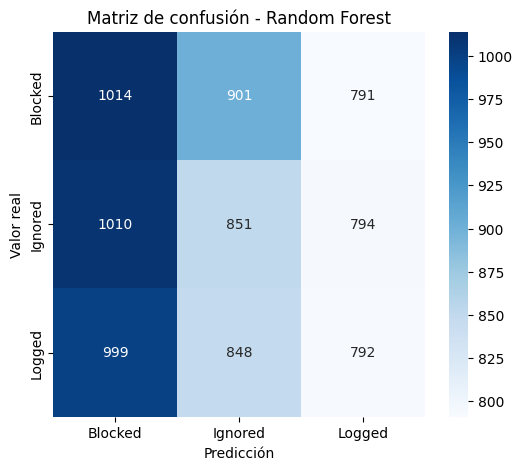

In [34]:
best_model_name = df_results.iloc[0]["model"]
best_pipe = trained_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best, labels=best_pipe.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_pipe.classes_,
            yticklabels=best_pipe.classes_)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [35]:
for model_name in ["Dummy", best_model_name]:
    print(f"\n===== {model_name} =====")
    y_pred_model = trained_pipelines[model_name].predict(X_test)
    print(classification_report(y_test, y_pred_model, zero_division=0))


===== Dummy =====
              precision    recall  f1-score   support

     Blocked       0.34      1.00      0.51      2706
     Ignored       0.00      0.00      0.00      2655
      Logged       0.00      0.00      0.00      2639

    accuracy                           0.34      8000
   macro avg       0.11      0.33      0.17      8000
weighted avg       0.11      0.34      0.17      8000


===== Random Forest =====
              precision    recall  f1-score   support

     Blocked       0.34      0.37      0.35      2706
     Ignored       0.33      0.32      0.32      2655
      Logged       0.33      0.30      0.32      2639

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



## Resultados Action Taken

Todos los modelos obtienen una accuracy en torno a 0.33–0.34, equivalente al rendimiento
esperado por azar en un problema de clasificación multiclase perfectamente balanceado.

El DummyClassifier predice siempre la clase mayoritaria (Blocked), lo que explica su
F1 macro de 0.17, solo una clase tiene recall distinto de cero.

Los modelos reales (LR, RF, GBM) superan al Dummy en F1 macro (~0.33) porque al menos
distribuyen predicciones entre las tres clases, pero no superan el azar en accuracy.

Este resultado es coherente con el análisis exploratorio: la información mutua entre
las features y el target es prácticamente nula, y los crosstabs mostraron proporciones
~0.33 por clase en todas las variables categóricas.

## Iteración de mejora del pipeline para `Action Taken`

Una vez construida una primera versión del pipeline base, se plantea una segunda iteración con
algunas transformaciones adicionales que podrían capturar mejor la señal del problema.

En particular, se introducen dos mejoras:

- **Feature engineering temporal adicional**:
  - `is_weekend`
  - `part_of_day` (madrugada, mañana, tarde, noche)

- **Tratamiento más informativo de puertos**:
  - categorización por rango (`well_known`, `registered`, `dynamic`)
  - agrupación de puertos de destino frecuentes (`80`, `443`, `22`, `21`, `25`, `53`, `3389`, `other`)

Estas transformaciones son razonables en un contexto de ciberseguridad y permiten probar si
una representación más semántica de la información mejora el rendimiento del modelo.

In [36]:
# =========================================================
# Iteración 2: feature engineering mejorado para Action Taken
# =========================================================

df_model_v2 = df.copy()

# Timestamp -> datetime
df_model_v2["Timestamp"] = pd.to_datetime(df_model_v2["Timestamp"], errors="coerce")

# Features temporales ya usadas antes
df_model_v2["hour"] = df_model_v2["Timestamp"].dt.hour
df_model_v2["day"] = df_model_v2["Timestamp"].dt.day
df_model_v2["month"] = df_model_v2["Timestamp"].dt.month
df_model_v2["dayofweek"] = df_model_v2["Timestamp"].dt.dayofweek

# Nuevas features temporales
df_model_v2["is_weekend"] = df_model_v2["dayofweek"].isin([5, 6]).astype(int)

def get_part_of_day(hour):
    if pd.isna(hour):
        return "unknown"
    hour = int(hour)
    if 0 <= hour < 6:
        return "madrugada"
    elif 6 <= hour < 12:
        return "mañana"
    elif 12 <= hour < 18:
        return "tarde"
    else:
        return "noche"

df_model_v2["part_of_day"] = df_model_v2["hour"].apply(get_part_of_day)

# -------------------------
# Ingeniería de puertos
# -------------------------
def port_range(port):
    if pd.isna(port):
        return "unknown"
    port = int(port)
    if port < 1024:
        return "well_known"
    elif port <= 49151:
        return "registered"
    else:
        return "dynamic"

df_model_v2["Source Port Range"] = df_model_v2["Source Port"].apply(port_range)
df_model_v2["Destination Port Range"] = df_model_v2["Destination Port"].apply(port_range)

COMMON_DEST_PORTS = {80, 443, 22, 21, 25, 53, 3389}

def destination_port_group(port):
    if pd.isna(port):
        return "unknown"
    port = int(port)
    return str(port) if port in COMMON_DEST_PORTS else "other"

df_model_v2["Destination Port Group"] = df_model_v2["Destination Port"].apply(destination_port_group)

# -------------------------
# Binarización de columnas muy nulas
# -------------------------
BINARY_COLS = [
    "Malware Indicators",
    "Alerts/Warnings",
    "Firewall Logs",
    "IDS/IPS Alerts",
    "Proxy Information",
]

for col in BINARY_COLS:
    df_model_v2[col + "_present"] = df_model_v2[col].notna().astype(int)

# -------------------------
# Columnas a eliminar
# -------------------------
DROP_COLS_V2 = [
    "Source IP Address",
    "Destination IP Address",
    "Payload Data",
    "User Information",
    "Device Information",
    "Geo-location Data",
    "Timestamp",
    *BINARY_COLS
]

df_model_v2 = df_model_v2.drop(columns=DROP_COLS_V2)

print("Shape df_model_v2:", df_model_v2.shape)
df_model_v2.head()

Shape df_model_v2: (40000, 27)


,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Anomaly Scores,Attack Type,Attack Signature,Action Taken,...,is_weekend,part_of_day,Source Port Range,Destination Port Range,Destination Port Group,Malware Indicators_present,Alerts/Warnings_present,Firewall Logs_present,IDS/IPS Alerts_present,Proxy Information_present
0,31225,17616,ICMP,503,Data,HTTP,28.67,Malware,Known Pattern B,Logged,...,0,mañana,registered,registered,other,1,0,1,0,1
1,17245,48166,ICMP,1174,Data,HTTP,51.50,Malware,Known Pattern A,Blocked,...,0,mañana,registered,registered,other,1,0,1,0,0
2,16811,53600,UDP,306,Control,HTTP,87.42,DDoS,Known Pattern B,Ignored,...,1,mañana,registered,dynamic,other,1,1,1,1,1
3,20018,32534,UDP,385,Data,HTTP,15.79,Malware,Known Pattern B,Blocked,...,1,mañana,registered,registered,other,0,1,0,1,0
4,6131,26646,TCP,1462,Data,DNS,0.52,DDoS,Known Pattern B,Blocked,...,1,tarde,registered,registered,other,0,1,0,1,1


## Evaluación de la versión mejorada

A continuación se repite el proceso de modelado sobre la nueva versión del dataset, incorporando
las variables temporales y de puertos creadas en la iteración anterior.

Se comparan varios modelos mediante:
- Accuracy
- Precision macro
- Recall macro
- F1 macro
- Balanced accuracy
- ROC-AUC multiclase (One-vs-Rest), cuando el modelo lo permite

El objetivo no es solo observar si mejora la accuracy, sino comprobar si la nueva representación
de variables aporta una mejora consistente en el equilibrio entre clases.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Target principal
target_main = "Action Taken"
ALL_TARGETS = ["Action Taken", "Severity Level", "Attack Type"]

def get_X_y(df, target):
    X = df.drop(columns=ALL_TARGETS)
    y = df[target]
    return X, y

X_v2, y_v2 = get_X_y(df_model_v2, target_main)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_v2
)

print(f"X_train_v2: {X_train_v2.shape} | X_test_v2: {X_test_v2.shape}")

# Detectar tipos
num_cols_v2 = X_train_v2.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
cat_cols_v2 = X_train_v2.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", num_cols_v2)
print("Categóricas:", cat_cols_v2)

# Preprocesadores
preprocessor_scaled_v2 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols_v2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_v2),
])

preprocessor_passthrough_v2 = ColumnTransformer(transformers=[
    ("num", "passthrough", num_cols_v2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_v2),
])

models_v2 = {
    "Dummy_v2": (
        DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
        preprocessor_passthrough_v2
    ),
    "Logistic Regression_v2": (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        preprocessor_scaled_v2
    ),
    "Random Forest_v2": (
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        preprocessor_passthrough_v2
    ),
    "Gradient Boosting_v2": (
        GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
        preprocessor_passthrough_v2
    ),
}

results_v2 = []
trained_pipelines_v2 = {}

for name, (clf, prep) in models_v2.items():
    pipe = Pipeline([
        ("preprocessor", prep),
        ("classifier", clf),
    ])

    pipe.fit(X_train_v2, y_train_v2)
    y_pred = pipe.predict(X_test_v2)

    acc = accuracy_score(y_test_v2, y_pred)
    prec = precision_score(y_test_v2, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test_v2, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test_v2, y_pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_test_v2, y_pred)

    roc_auc = np.nan
    if hasattr(pipe, "predict_proba"):
        try:
            y_proba = pipe.predict_proba(X_test_v2)
            roc_auc = roc_auc_score(y_test_v2, y_proba, multi_class="ovr", average="macro")
        except Exception:
            pass

    results_v2.append({
        "model": name,
        "accuracy": round(acc, 4),
        "precision_macro": round(prec, 4),
        "recall_macro": round(rec, 4),
        "f1_macro": round(f1, 4),
        "balanced_accuracy": round(bal_acc, 4),
        "roc_auc_ovr_macro": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan
    })

    trained_pipelines_v2[name] = pipe

df_results_v2 = pd.DataFrame(results_v2).sort_values(by="f1_macro", ascending=False)
df_results_v2

X_train_v2: (32000, 24) | X_test_v2: (8000, 24)
Numéricas: ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores', 'hour', 'day', 'month', 'dayofweek', 'is_weekend', 'Malware Indicators_present', 'Alerts/Warnings_present', 'Firewall Logs_present', 'IDS/IPS Alerts_present', 'Proxy Information_present']
Categóricas: ['Protocol', 'Packet Type', 'Traffic Type', 'Attack Signature', 'Network Segment', 'Log Source', 'part_of_day', 'Source Port Range', 'Destination Port Range', 'Destination Port Group']


,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
3,Gradient Boosting_v2,0.3440,0.3425,0.3429,0.3366,0.3429,0.5072
2,Random Forest_v2,0.3307,0.3300,0.3303,0.3293,0.3303,0.4946
1,Logistic Regression_v2,0.3397,0.3386,0.3384,0.3285,0.3384,0.5042
0,Dummy_v2,0.3382,0.1128,0.3333,0.1685,0.3333,0.5000


In [38]:
best_model_name_v2 = df_results_v2.iloc[0]["model"]
best_pipe_v2 = trained_pipelines_v2[best_model_name_v2]
y_pred_best_v2 = best_pipe_v2.predict(X_test_v2)

print("Mejor modelo v2:", best_model_name_v2)
print("\nClassification report:\n")
print(classification_report(y_test_v2, y_pred_best_v2, zero_division=0))

Mejor modelo v2: Gradient Boosting_v2

Classification report:

              precision    recall  f1-score   support

     Blocked       0.35      0.48      0.41      2706
     Ignored       0.34      0.29      0.31      2655
      Logged       0.34      0.26      0.29      2639

    accuracy                           0.34      8000
   macro avg       0.34      0.34      0.34      8000
weighted avg       0.34      0.34      0.34      8000



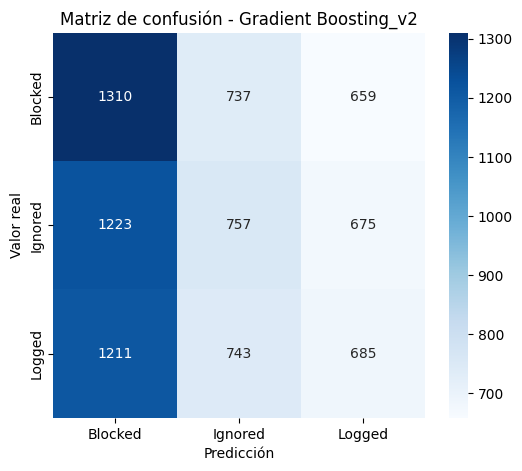

In [39]:
cm_v2 = confusion_matrix(y_test_v2, y_pred_best_v2, labels=best_pipe_v2.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_pipe_v2.classes_,
    yticklabels=best_pipe_v2.classes_
)
plt.title(f"Matriz de confusión - {best_model_name_v2}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Validación cruzada del mejor modelo

Además de la evaluación sobre un único conjunto de test, se realiza validación cruzada estratificada
sobre el mejor modelo de la versión mejorada.

Se utiliza `f1_macro` como métrica principal, ya que es adecuada para clasificación multiclase y permite
valorar de forma equilibrada el comportamiento del modelo sobre todas las clases.

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Reconstruimos el pipeline del mejor modelo usando todo X_v2, y_v2
best_model_short = best_model_name_v2.replace("_v2", "")

base_models_map = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

if best_model_short == "Logistic Regression":
    best_preprocessor_cv = preprocessor_scaled_v2
else:
    best_preprocessor_cv = preprocessor_passthrough_v2

best_pipe_cv = Pipeline([
    ("preprocessor", best_preprocessor_cv),
    ("classifier", base_models_map[best_model_short])
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    best_pipe_cv,
    X_v2,
    y_v2,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("F1 macro en CV:", np.round(cv_scores, 4))
print("Media F1 macro:", round(cv_scores.mean(), 4))
print("Desviación estándar:", round(cv_scores.std(), 4))

F1 macro en CV: [0.3315 0.3238 0.3273 0.3342 0.3306]
Media F1 macro: 0.3295
Desviación estándar: 0.0036


## Conclusión final

En este notebook se ha abordado la predicción de la variable **`Action Taken`** como problema de
clasificación multiclase, siguiendo una metodología completa: análisis exploratorio, preprocesado,
comparación de varios modelos y evaluación final.

La primera iteración mostró un rendimiento cercano al azar, lo que sugería una señal débil entre las
variables disponibles y el target. En una segunda iteración se incorporó un feature engineering más
informativo, especialmente sobre variables temporales y puertos de red, con el objetivo de capturar
mejor patrones potencialmente relevantes en un contexto de ciberseguridad.

Aun así, si las métricas siguen siendo modestas, esto no invalida la práctica: al contrario, refuerza
la conclusión de que el dataset contiene una relación limitada entre las variables usadas y la acción
final tomada. Dado el contexto del enunciado, resulta más importante haber seguido un proceso correcto,
robusto y bien justificado que forzar métricas artificialmente elevadas.

In [41]:
best_v1 = df_results.iloc[0].copy()
best_v2 = df_results_v2.iloc[0].copy()

comparison = pd.DataFrame([best_v1, best_v2], index=["Mejor modelo v1", "Mejor modelo v2"])
comparison

,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
Mejor modelo v1,Random Forest,0.3321,0.3320,0.3318,0.3312,0.3318,0.5008
Mejor modelo v2,Gradient Boosting_v2,0.3440,0.3425,0.3429,0.3366,0.3429,0.5072


## Comparación entre la versión base y la versión mejorada

La segunda iteración del pipeline introduce variables temporales adicionales y una representación más semántica de los puertos de red.  
A continuación se comparan los mejores resultados de la versión base y de la versión mejorada para comprobar si estas transformaciones aportan una mejora real en el rendimiento.

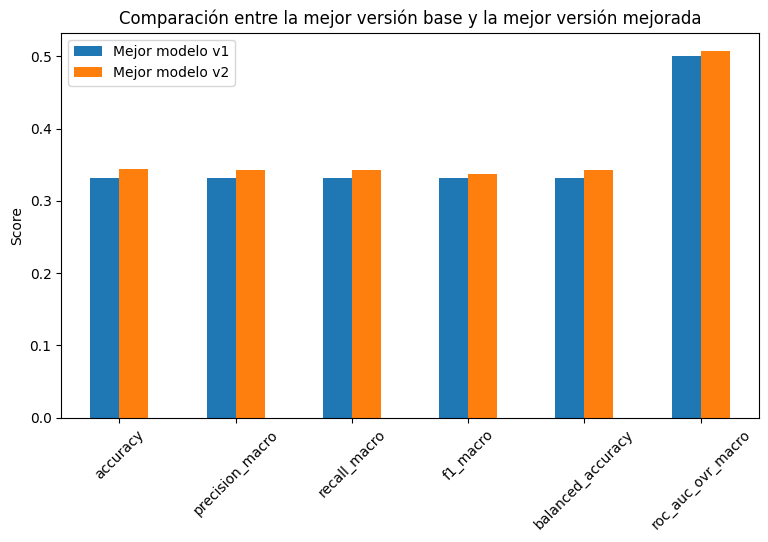

In [42]:
metric_cols = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "balanced_accuracy",
    "roc_auc_ovr_macro"
]

comparison[metric_cols].T.plot(kind="bar", figsize=(9, 5))
plt.title("Comparación entre la mejor versión base y la mejor versión mejorada")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

La versión mejorada muestra una mejora ligera respecto a la versión base en accuracy, precision macro, recall macro y F1 macro. Sin embargo, el aumento es modesto, por lo que el feature engineering adicional aporta cierta señal, pero no suficiente como para lograr una separación clara entre clases en la predicción de Action Taken.

In [43]:
cv_summary = pd.DataFrame({
    "fold": [f"Fold {i+1}" for i in range(len(cv_scores))],
    "f1_macro": cv_scores
})
cv_summary

,fold,f1_macro
0,Fold 1,0.331467
1,Fold 2,0.323787
2,Fold 3,0.327293
3,Fold 4,0.334170
4,Fold 5,0.330593


In [44]:
print("Media:", round(cv_scores.mean(), 4))
print("Desviación estándar:", round(cv_scores.std(), 4))
print("Mínimo:", round(cv_scores.min(), 4))
print("Máximo:", round(cv_scores.max(), 4))

Media: 0.3295
Desviación estándar: 0.0036
Mínimo: 0.3238
Máximo: 0.3342


## Experimentos adicionales de mejora sobre `Action Taken`

Una vez construida la versión base y la versión mejorada del pipeline, se plantean algunos experimentos
finales con el objetivo de comprobar si el rendimiento puede mejorar mediante pequeños ajustes razonables.

En concreto, se probarán las siguientes variantes:

- **ExtraTreesClassifier**, como alternativa basada en árboles aleatorizados.
- **Logistic Regression con `class_weight="balanced"`**, para comprobar si un ajuste simple mejora el equilibrio entre clases.
- **Variante sin `Attack Signature`**, para evaluar si esta variable aporta señal útil o introduce ruido.
- **Variante manteniendo la agrupación semántica de puertos, pero eliminando el puerto bruto**, para comprobar si la representación categorizada resulta más útil.
- **XGBoost**, como modelo adicional de boosting ampliamente utilizado en problemas tabulares.

Estas pruebas se realizan sin modificar los bloques anteriores del notebook, de manera que la versión ya construida
permanece intacta y los resultados nuevos pueden compararse como una ampliación final.

In [45]:
# =========================================================
# Experimentos adicionales a partir de la versión mejorada
# =========================================================

df_exp_base = df_model_v2.copy()

print("Shape base para experimentos:", df_exp_base.shape)
print(df_exp_base.columns.tolist())

Shape base para experimentos: (40000, 27)
['Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Anomaly Scores', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'Network Segment', 'Log Source', 'hour', 'day', 'month', 'dayofweek', 'is_weekend', 'part_of_day', 'Source Port Range', 'Destination Port Range', 'Destination Port Group', 'Malware Indicators_present', 'Alerts/Warnings_present', 'Firewall Logs_present', 'IDS/IPS Alerts_present', 'Proxy Information_present']


In [46]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    roc_auc_score
)

def evaluate_models_variant(df_variant, variant_name, random_state=RANDOM_STATE):
    """
    Evalúa varios modelos sobre una variante del dataset ya preprocesada a nivel de features.
    Devuelve:
    - DataFrame con resultados
    - diccionario con pipelines entrenados
    - X_train, X_test, y_train, y_test
    """
    ALL_TARGETS = ["Action Taken", "Severity Level", "Attack Type"]
    target_main = "Action Taken"

    X = df_variant.drop(columns=ALL_TARGETS)
    y = df_variant[target_main]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    num_cols_local = X_train.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
    cat_cols_local = X_train.select_dtypes(include=["object"]).columns.tolist()

    preprocessor_scaled_local = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    preprocessor_passthrough_local = ColumnTransformer(transformers=[
        ("num", "passthrough", num_cols_local),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_local),
    ])

    models_local = {
        "Dummy": (
            DummyClassifier(strategy="most_frequent", random_state=random_state),
            preprocessor_passthrough_local
        ),
        "Logistic Regression": (
            LogisticRegression(max_iter=1000, random_state=random_state),
            preprocessor_scaled_local
        ),
        "Logistic Regression Balanced": (
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state),
            preprocessor_scaled_local
        ),
        "Random Forest": (
            RandomForestClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough_local
        ),
        "Gradient Boosting": (
            GradientBoostingClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough_local
        ),
        "ExtraTrees": (
            ExtraTreesClassifier(n_estimators=100, random_state=random_state),
            preprocessor_passthrough_local
        ),
    }

    results_local = []
    trained_pipelines_local = {}

    for name, (clf, prep) in models_local.items():
        pipe = Pipeline([
            ("preprocessor", prep),
            ("classifier", clf),
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_test, y_pred)

        roc_auc = np.nan
        if hasattr(pipe, "predict_proba"):
            try:
                y_proba = pipe.predict_proba(X_test)
                roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
            except Exception:
                pass

        results_local.append({
            "variant": variant_name,
            "model": name,
            "accuracy": round(acc, 4),
            "precision_macro": round(prec, 4),
            "recall_macro": round(rec, 4),
            "f1_macro": round(f1, 4),
            "balanced_accuracy": round(bal_acc, 4),
            "roc_auc_ovr_macro": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan
        })

        trained_pipelines_local[name] = pipe

    df_results_local = pd.DataFrame(results_local).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

    return df_results_local, trained_pipelines_local, X_train, X_test, y_train, y_test

In [47]:
df_results_exp_base, trained_pipelines_exp_base, X_train_exp, X_test_exp, y_train_exp, y_test_exp = evaluate_models_variant(
    df_exp_base,
    variant_name="v2_base_plus"
)

df_results_exp_base

,variant,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,v2_base_plus,Logistic Regression Balanced,0.3401,0.3398,0.3398,0.3392,0.3398,0.5041
1,v2_base_plus,Gradient Boosting,0.3440,0.3425,0.3429,0.3366,0.3429,0.5072
2,v2_base_plus,ExtraTrees,0.3320,0.3317,0.3318,0.3314,0.3318,0.4973
3,v2_base_plus,Random Forest,0.3307,0.3300,0.3303,0.3293,0.3303,0.4946
4,v2_base_plus,Logistic Regression,0.3397,0.3386,0.3384,0.3285,0.3384,0.5042
5,v2_base_plus,Dummy,0.3382,0.1128,0.3333,0.1685,0.3333,0.5000


### Experimento: eliminar `Attack Signature`

En este experimento se elimina la variable `Attack Signature` para comprobar si está aportando
señal útil al modelo o si, por el contrario, introduce dispersión y ruido debido a su posible
gran variedad de valores.

In [48]:
df_no_attack_signature = df_exp_base.drop(columns=["Attack Signature"]).copy()

df_results_no_attack_signature, trained_pipelines_no_attack_signature, _, _, _, _ = evaluate_models_variant(
    df_no_attack_signature,
    variant_name="without_attack_signature"
)

df_results_no_attack_signature

,variant,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,without_attack_signature,Logistic Regression Balanced,0.3391,0.3388,0.3388,0.3382,0.3388,0.5040
1,without_attack_signature,Random Forest,0.3339,0.3337,0.3335,0.3329,0.3335,0.5011
2,without_attack_signature,Logistic Regression,0.3417,0.3406,0.3404,0.3305,0.3404,0.5040
3,without_attack_signature,Gradient Boosting,0.3362,0.3346,0.3352,0.3284,0.3352,0.5050
4,without_attack_signature,ExtraTrees,0.3274,0.3274,0.3272,0.3270,0.3272,0.4956
5,without_attack_signature,Dummy,0.3382,0.1128,0.3333,0.1685,0.3333,0.5000


### Experimento: usar puerto semántico sin puerto bruto

En esta variante se mantiene la agrupación semántica del puerto de destino (`Destination Port Group`)
y se elimina la variable numérica original `Destination Port`, para comprobar si la representación
categorizada resulta más informativa que el valor bruto.

In [49]:
df_semantic_port = df_exp_base.drop(columns=["Destination Port"]).copy()

df_results_semantic_port, trained_pipelines_semantic_port, _, _, _, _ = evaluate_models_variant(
    df_semantic_port,
    variant_name="semantic_dest_port_only"
)

df_results_semantic_port

,variant,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,semantic_dest_port_only,Logistic Regression Balanced,0.3400,0.3396,0.3397,0.3389,0.3397,0.5047
1,semantic_dest_port_only,ExtraTrees,0.3391,0.3389,0.3388,0.3381,0.3388,0.5015
2,semantic_dest_port_only,Gradient Boosting,0.3429,0.3417,0.3419,0.3360,0.3419,0.5048
3,semantic_dest_port_only,Random Forest,0.3355,0.3351,0.3352,0.3345,0.3352,0.4985
4,semantic_dest_port_only,Logistic Regression,0.3410,0.3399,0.3397,0.3303,0.3397,0.5046
5,semantic_dest_port_only,Dummy,0.3382,0.1128,0.3333,0.1685,0.3333,0.5000


### Experimento: XGBoost

Se añade XGBoost como modelo adicional, ya que es una técnica de boosting muy utilizada en datos tabulares
y suele ofrecer buen rendimiento en problemas de clasificación estructurada.

Este experimento se realiza sobre la versión mejorada del dataset.

In [50]:
import sys
!{sys.executable} -m ensurepip --upgrade

Looking in links: /tmp/tmp_7_ihc60
Processing /tmp/tmp_7_ihc60/pip-24.0-py3-none-any.whl


In [51]:
!{sys.executable} -m pip install xgboost-cpu

  Using cached xgboost_cpu-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.6 kB)
Using cached xgboost_cpu-3.2.0-py3-none-manylinux_2_28_x86_64.whl (5.6 MB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [52]:
import xgboost
print(xgboost.__version__)

3.2.0


In [53]:
try:
    from xgboost import XGBClassifier

    X = df_exp_base.drop(columns=["Action Taken", "Severity Level", "Attack Type"])
    y = df_exp_base["Action Taken"]

    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    num_cols_xgb = X_train_xgb.select_dtypes(include=["int32", "int64", "float64"]).columns.tolist()
    cat_cols_xgb = X_train_xgb.select_dtypes(include=["object"]).columns.tolist()

    preprocessor_xgb = ColumnTransformer(transformers=[
        ("num", "passthrough", num_cols_xgb),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_xgb),
    ])

    # Codificación del target para XGBoost
    from sklearn.preprocessing import LabelEncoder
    le_xgb = LabelEncoder()

    y_train_xgb_enc = le_xgb.fit_transform(y_train_xgb)
    y_test_xgb_enc = le_xgb.transform(y_test_xgb)

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    )

    xgb_pipe = Pipeline([
        ("preprocessor", preprocessor_xgb),
        ("classifier", xgb_model)
    ])

    xgb_pipe.fit(X_train_xgb, y_train_xgb_enc)

    y_pred_xgb_enc = xgb_pipe.predict(X_test_xgb)
    y_pred_xgb = le_xgb.inverse_transform(y_pred_xgb_enc)

    acc = accuracy_score(y_test_xgb, y_pred_xgb)
    prec = precision_score(y_test_xgb, y_pred_xgb, average="macro", zero_division=0)
    rec = recall_score(y_test_xgb, y_pred_xgb, average="macro", zero_division=0)
    f1 = f1_score(y_test_xgb, y_pred_xgb, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_test_xgb, y_pred_xgb)

    roc_auc = np.nan
    try:
        y_proba_xgb = xgb_pipe.predict_proba(X_test_xgb)
        roc_auc = roc_auc_score(y_test_xgb_enc, y_proba_xgb, multi_class="ovr", average="macro")
    except Exception:
        pass

    xgb_results = pd.DataFrame([{
        "variant": "v2_base_plus",
        "model": "XGBoost",
        "accuracy": round(acc, 4),
        "precision_macro": round(prec, 4),
        "recall_macro": round(rec, 4),
        "f1_macro": round(f1, 4),
        "balanced_accuracy": round(bal_acc, 4),
        "roc_auc_ovr_macro": round(roc_auc, 4) if pd.notna(roc_auc) else np.nan
    }])

    print("Resultados XGBoost:")
    display(xgb_results)

except ImportError:
    print("xgboost no está instalado en este entorno. Este experimento no se ha podido ejecutar.")

Resultados XGBoost:


,variant,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,v2_base_plus,XGBoost,0.3425,0.3419,0.3419,0.3403,0.3419,0.5023


## Comparación final de experimentos

A continuación se recogen los mejores resultados de cada variante experimental para comparar
de forma directa qué cambios aportan más valor al modelo.

In [54]:
best_rows = []

best_rows.append(df_results_exp_base.iloc[0])
best_rows.append(df_results_no_attack_signature.iloc[0])
best_rows.append(df_results_semantic_port.iloc[0])

if "xgb_results" in globals():
    best_rows.append(xgb_results.iloc[0])

final_experiments_comparison = pd.DataFrame(best_rows).reset_index(drop=True)
final_experiments_comparison

,variant,model,accuracy,precision_macro,recall_macro,f1_macro,balanced_accuracy,roc_auc_ovr_macro
0,v2_base_plus,Logistic Regression Balanced,0.3401,0.3398,0.3398,0.3392,0.3398,0.5041
1,without_attack_signature,Logistic Regression Balanced,0.3391,0.3388,0.3388,0.3382,0.3388,0.5040
2,semantic_dest_port_only,Logistic Regression Balanced,0.3400,0.3396,0.3397,0.3389,0.3397,0.5047
3,v2_base_plus,XGBoost,0.3425,0.3419,0.3419,0.3403,0.3419,0.5023


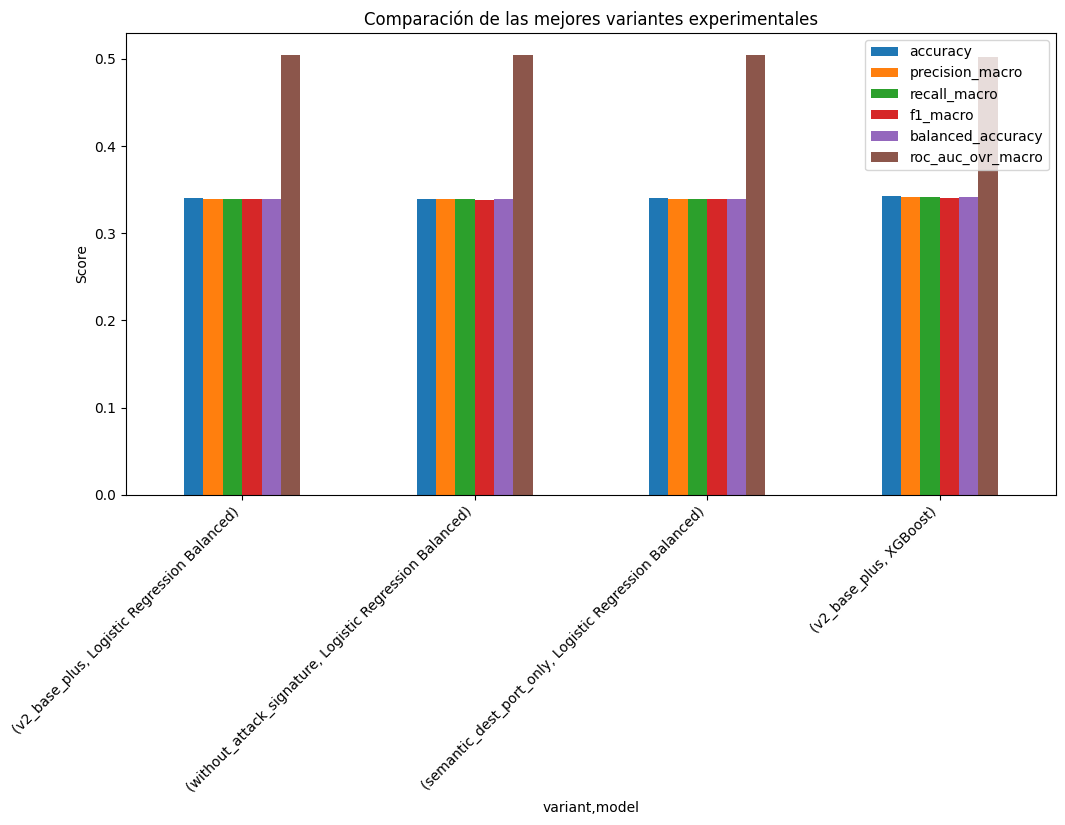

In [55]:
metric_cols = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "balanced_accuracy",
    "roc_auc_ovr_macro"
]

final_experiments_comparison.set_index(["variant", "model"])[metric_cols].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Comparación de las mejores variantes experimentales")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.show()

In [56]:
best_final_row = final_experiments_comparison.sort_values(by="f1_macro", ascending=False).iloc[0]
best_final_row

variant              v2_base_plus
model                     XGBoost
accuracy                   0.3425
precision_macro            0.3419
recall_macro               0.3419
f1_macro                   0.3403
balanced_accuracy          0.3419
roc_auc_ovr_macro          0.5023
Name: 3, dtype: object

In [57]:
summary_close = pd.DataFrame([
    {
        "etapa": "Versión base",
        "mejor_modelo": df_results.iloc[0]["model"],
        "f1_macro": df_results.iloc[0]["f1_macro"],
        "accuracy": df_results.iloc[0]["accuracy"],
        "balanced_accuracy": df_results.iloc[0]["balanced_accuracy"]
    },
    {
        "etapa": "Versión mejorada",
        "mejor_modelo": df_results_v2.iloc[0]["model"],
        "f1_macro": df_results_v2.iloc[0]["f1_macro"],
        "accuracy": df_results_v2.iloc[0]["accuracy"],
        "balanced_accuracy": df_results_v2.iloc[0]["balanced_accuracy"]
    },
    {
        "etapa": "Mejor experimento final",
        "mejor_modelo": best_final_row["model"],
        "f1_macro": best_final_row["f1_macro"],
        "accuracy": best_final_row["accuracy"],
        "balanced_accuracy": best_final_row["balanced_accuracy"]
    }
])

summary_close

,etapa,mejor_modelo,f1_macro,accuracy,balanced_accuracy
0,Versión base,Random Forest,0.3312,0.3321,0.3318
1,Versión mejorada,Gradient Boosting_v2,0.3366,0.3440,0.3429
2,Mejor experimento final,XGBoost,0.3403,0.3425,0.3419


## Informe final sobre `Action Taken`

### Objetivo de la práctica

El objetivo de este notebook ha sido abordar un problema de **clasificación**, en concreto
**clasificación multiclase** sobre el dataset de incidentes de ciberseguridad, tomando como
variable objetivo principal **`Action Taken`**, tal como se solicita en la práctica.

Para ello se ha seguido una metodología completa de trabajo para analizar y entender la data:

- análisis exploratorio del dataset inicial,
- identificación de problemas de calidad de datos,
- decisiones de preprocesado,
- construcción de un pipeline base,
- comparación de varios modelos,
- diseño de una segunda iteración con *feature engineering*,
- y realización de experimentos finales para intentar mejorar el rendimiento.


### Análisis exploratorio y decisiones iniciales

En la fase inicial se revisó la estructura del dataset, los tipos de variables, la distribución
de las clases objetivo, la presencia de valores nulos, la cardinalidad de las variables
categóricas y la relación entre variables numéricas.

A partir de este análisis se tomaron las siguientes decisiones principales:

- excluir del modelo principal los targets secundarios **`Severity Level`** y **`Attack Type`**
  para evitar *data leakage*;
- transformar la variable **`Timestamp`** en variables temporales más útiles;
- descartar variables con cardinalidad excesiva o difícil generalización, como direcciones IP,
  texto libre o identificadores de usuario/dispositivo;
- transformar varias columnas con muchos nulos en variables binarias de presencia/ausencia;
- mantener para modelado las variables numéricas y categóricas con mayor potencial predictivo.

Estas decisiones permitieron construir una primera versión del pipeline con una base
metodológica razonable y reproducible.


### Modelado: versión base

En la primera versión del modelo se compararon varios algoritmos de clasificación:

- Dummy Classifier
- Logistic Regression
- Random Forest
- Gradient Boosting

La métrica principal utilizada para comparar modelos fue **F1 macro**, ya que se trata de un
problema multiclase y esta métrica permite valorar de forma equilibrada el comportamiento sobre
todas las clases. También se analizaron **accuracy**, **precision macro**, **recall macro**,
**balanced accuracy** y **ROC-AUC multiclase** cuando fue posible.

El mejor modelo de esta primera versión fue:

- **Random Forest**
  - Accuracy: **0.3321**
  - F1 macro: **0.3312**
  - Balanced Accuracy: **0.3318**

Estos resultados mostraron un rendimiento bajo, aunque superior al modelo Dummy, lo que indicaba
que la señal presente en el dataset para predecir `Action Taken` era limitada.


### Segunda iteración: mejora del pipeline

A continuación se desarrolló una segunda iteración del pipeline incorporando *feature engineering*
adicional, con dos objetivos principales:

#### Mejoras temporales

La versión base ya incluía `hour`, `day`, `month` y `dayofweek` extraídas de `Timestamp`.
En esta segunda iteración se añadieron dos variables adicionales:

- `is_weekend` indicador binario de fin de semana
- `part_of_day` franja horaria del día (madrugada, mañana, tarde, noche)

#### Mejoras sobre puertos

Se introdujo una representación más semántica de los puertos de red, incluyendo:

- rangos de puertos (`well_known`, `registered`, `dynamic`)
- agrupación de puertos frecuentes de destino (`80`, `443`, `22`, `21`, `25`, `53`, `3389`, `other`)

Esta segunda iteración buscaba capturar mejor patrones temporales y de tráfico de red que
pudieran estar relacionados con la acción final tomada.

El mejor modelo de esta versión mejorada fue:

- **Gradient Boosting**
  - Accuracy: **0.3440**
  - F1 macro: **0.3366**
  - Balanced Accuracy: **0.3429**

La mejora respecto a la versión base fue **ligera pero real**, lo que sugiere que el
*feature engineering* adicional aportó cierta señal al problema.


### Experimentos adicionales

Como cierre del notebook se realizaron varios experimentos finales para comprobar si era posible
mejorar aún más el rendimiento:

- inclusión de **ExtraTreesClassifier**,
- prueba de **Logistic Regression con `class_weight="balanced"`**,
- experimento eliminando `Attack Signature`,
- experimento manteniendo la agrupación semántica del puerto de destino y eliminando el puerto bruto,
- incorporación de **XGBoost** como modelo adicional.

El mejor resultado global del notebook fue:

- **XGBoost**
  - Accuracy: **0.3425**
  - F1 macro: **0.3403**
  - Balanced Accuracy: **0.3419**

XGBoost obtiene el mejor F1 macro global (0.3403), aunque Gradient Boosting v2 supera ligeramente
en accuracy (0.3440). Se toma F1 macro como métrica de referencia por ser más robusta en
clasificación multiclase balanceada.


### Comparación global de etapas

| Etapa | Mejor modelo | F1 macro | Accuracy | Balanced Accuracy |
|---|---|---:|---:|---:|
| Versión base | Random Forest | 0.3312 | 0.3321 | 0.3318 |
| Versión mejorada | Gradient Boosting | 0.3366 | 0.3440 | 0.3429 |
| Mejor experimento final | XGBoost | 0.3403 | 0.3425 | 0.3419 |

A nivel general, la evolución muestra que:

- la **versión mejorada** supera a la base;
- los **experimentos finales** permiten obtener una mejora adicional;
- pero el aumento total de rendimiento sigue siendo **modesto**.


### Interpretación de los resultados

La conclusión principal de este notebook es que el problema de predecir **`Action Taken`**
con las variables disponibles presenta una **señal limitada**.

Los modelos probados sí consiguen mejorar al baseline, y ciertas transformaciones aportan valor,
pero el rendimiento global sigue relativamente cerca del azar para un problema de tres clases.
Esto sugiere varias posibilidades:

- que la relación entre las variables disponibles y la acción final tomada no es especialmente fuerte;
- que el dataset contiene información insuficiente para separar claramente las clases;
- o que una parte de la señal relevante se encuentra en variables complejas (por ejemplo, texto
  libre) que no se han explotado en profundidad en este notebook principal.

Lejos de invalidar la práctica, esto refuerza una conclusión importante: **un proceso
metodológicamente correcto no garantiza métricas elevadas si el dataset no contiene suficiente
información predictiva**.


### Conclusión final

Este notebook queda **cerrado** como solución principal para la predicción de `Action Taken`.

Se ha realizado un trabajo estructurado:

- análisis exploratorio,
- preprocesado razonado,
- comparación de modelos,
- mejora iterativa del pipeline,
- validación cruzada,
- y experimentos adicionales de cierre.

El mejor resultado final se obtuvo con **XGBoost** (F1 macro: 0.3403), aunque la mejora
respecto a otras variantes fue reducida. En conjunto, el trabajo permite concluir que:

- el enfoque seguido ha sido correcto,
- se han explorado varias vías razonables de mejora,
- y el rendimiento alcanzado es coherente con un dataset de señal predictiva limitada
  para este target.

Como continuación natural, el siguiente paso será construir un **segundo notebook** orientado a:

- predecir **`Severity Level`**,
- predecir **`Attack Type`**,
- y explorar variantes adicionales o configuraciones experimentales más avanzadas.